# PINN flux reconstruction - Koppel-Martin Case 1

Nonconforming mixed-dimensional LCG solve on a thin 3D slab with an
independent 1D fracture mesh, followed by a ghost-partition PINN flux
reconstruction.

The neural network represents the thickness-integrated matrix flux
`Q = int q_xy dz`.  Therefore the nonconforming cell balance is
`int_{partial K_xy} Q.n ds = int_{Gamma cap K} lambda_h ds` because
the Koppel-Martin test has zero matrix source.


In [1]:
from mpi4py import MPI
import gmsh
import pathlib
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import LogNorm
import ufl
import basix.ufl
import torch
import torch.nn as nn
from tqdm.auto import tqdm

from dolfinx import fem, geometry
from dolfinx.io import gmsh as gmshio
from fenicsx_ii import Average, Circle, LinearProblem

comm = MPI.COMM_WORLD
rank = comm.rank
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(1234)
np.random.seed(1234)

REF = 5
ORDER = 1
THICKNESS = 0.02
Z_FRACTURE = 0.5 * THICKNESS

K_M_VALUE = 1.0
K_F_VALUE = 10.0

# Same endpoints as mixed_dimensional_problem_validation5_nonconforming.ipynb.
# The paper endpoints are (0.25, 0.0) and (0.75, 1.0); the small inset
# avoids circular averaging exactly at the bulk boundary.
FRAC_A = np.array([0.25, 0.01], dtype=float)
FRAC_B = np.array([0.75, 0.99], dtype=float)
TIP_FRAC = 0.05

MESH_CACHE_DIR = pathlib.Path("fracture_problem_nonconforming_km") / "meshes"
OMEGA_MESH_DIR_CANDIDATES = [
    pathlib.Path("."),
    pathlib.Path("fenicsx/code"),
    pathlib.Path("fenicsx/code/fracture problem"),
]

def close_gmsh():
    try:
        if gmsh.isInitialized():
            gmsh.finalize()
    except Exception:
        pass

/home/muchamad/PhD/fenicsx/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def estimate_bulk_h(omega):
    coords = omega.geometry.x
    def min_positive_spacing(values):
        vals = np.unique(np.round(np.sort(values), 14))
        diffs = np.diff(vals)
        diffs = diffs[diffs > 1.0e-12]
        return float(diffs.min()) if diffs.size else np.inf
    return min(min_positive_spacing(coords[:, 0]), min_positive_spacing(coords[:, 1]))

def omega_mesh_path(ref):
    name = f"Omega_ex1_{ref}.msh"
    for folder in OMEGA_MESH_DIR_CANDIDATES:
        path = folder / name
        if path.exists():
            return path
    return None

def make_structured_slab_mesh(ref):
    h = 1.0 / (2 ** (ref + 1))
    n = int(round(1.0 / h))
    MESH_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    path = MESH_CACHE_DIR / f"Omega_ex1_{ref}.msh"
    if path.exists():
        return path

    close_gmsh()
    gmsh.initialize()
    gmsh.option.setNumber("General.Terminal", 0)
    gmsh.model.add("Omega_KM_case1")
    p1 = gmsh.model.occ.addPoint(0.0, 0.0, 0.0)
    p2 = gmsh.model.occ.addPoint(1.0, 0.0, 0.0)
    p3 = gmsh.model.occ.addPoint(1.0, 1.0, 0.0)
    p4 = gmsh.model.occ.addPoint(0.0, 1.0, 0.0)
    l1 = gmsh.model.occ.addLine(p1, p2)
    l2 = gmsh.model.occ.addLine(p2, p3)
    l3 = gmsh.model.occ.addLine(p3, p4)
    l4 = gmsh.model.occ.addLine(p4, p1)
    cl = gmsh.model.occ.addCurveLoop([l1, l2, l3, l4])
    surf = gmsh.model.occ.addPlaneSurface([cl])
    gmsh.model.occ.synchronize()
    for line in [l1, l2, l3, l4]:
        gmsh.model.mesh.setTransfiniteCurve(line, n + 1)
    gmsh.model.mesh.setTransfiniteSurface(surf)
    gmsh.model.mesh.setRecombine(2, surf)
    gmsh.option.setNumber("Mesh.RecombinationAlgorithm", 2)
    gmsh.model.occ.extrude([(2, surf)], 0.0, 0.0, THICKNESS, numElements=[1], recombine=True)
    gmsh.model.occ.synchronize()
    vols = [tag for _, tag in gmsh.model.getEntities(dim=3)]
    pg = gmsh.model.addPhysicalGroup(3, vols)
    gmsh.model.setPhysicalName(3, pg, "Omega")
    gmsh.model.mesh.generate(3)
    if rank == 0:
        gmsh.write(str(path))
    close_gmsh()
    comm.barrier()
    return path

def gamma_cache_path(ref, h, h_gamma):
    tag = (
        f"ref{ref}_h{h:.8f}"
        f"_hg{h_gamma:.8f}"
        f"_a{FRAC_A[0]:.3f}_{FRAC_A[1]:.3f}"
        f"_b{FRAC_B[0]:.3f}_{FRAC_B[1]:.3f}"
    ).replace(".", "p")
    return MESH_CACHE_DIR / f"Gamma_KM_{tag}.msh"

def make_nonconforming_meshes(ref):
    path = omega_mesh_path(ref)
    if path is None:
        path = make_structured_slab_mesh(ref)
    omega = gmshio.read_from_msh(str(path), comm, 0, gdim=3)[0]
    h = estimate_bulk_h(omega)
    h_gamma = 3 * h
    gamma_path = gamma_cache_path(ref, h, h_gamma)
    if gamma_path.exists():
        gamma = gmshio.read_from_msh(str(gamma_path), comm, 0, gdim=3)[0]
        return omega, gamma, h, h_gamma, path, gamma_path

    close_gmsh()
    gmsh.initialize()
    gmsh.option.setNumber("General.Terminal", 0)
    gmsh.model.add("Gamma_KM_case1")
    p0 = gmsh.model.occ.addPoint(FRAC_A[0], FRAC_A[1], Z_FRACTURE)
    p1 = gmsh.model.occ.addPoint(FRAC_B[0], FRAC_B[1], Z_FRACTURE)
    line = gmsh.model.occ.addLine(p0, p1)
    gmsh.model.occ.synchronize()
    gmsh.model.mesh.setSize([(0, p0), (0, p1)], h_gamma)
    pg = gmsh.model.addPhysicalGroup(1, [line])
    gmsh.model.setPhysicalName(1, pg, "Gamma")
    gmsh.model.mesh.generate(1)
    if rank == 0:
        gamma_path.parent.mkdir(parents=True, exist_ok=True)
        gmsh.write(str(gamma_path))
    gamma = gmshio.model_to_mesh(gmsh.model, comm, 0, gdim=3)[0]
    close_gmsh()
    comm.barrier()
    return omega, gamma, h, h_gamma, path, gamma_path


In [3]:
def unit(v):
    v = np.asarray(v, dtype=float)
    nrm = np.linalg.norm(v)
    if nrm == 0.0:
        raise ValueError("zero-length vector")
    return v / nrm

tau_np = unit(FRAC_B - FRAC_A)
normal_np = np.array([-tau_np[1], tau_np[0]], dtype=float)
L_gamma = float(np.linalg.norm(FRAC_B - FRAC_A))

def real_points_np(s, z_value=Z_FRACTURE):
    s = np.asarray(s, dtype=float).reshape(-1)
    xy = FRAC_A[None, :] + s[:, None] * tau_np[None, :]
    return np.column_stack([xy, np.full(len(xy), z_value)])

def signed_distance_np(points):
    return (np.asarray(points, dtype=float)[:, :2] - FRAC_A) @ normal_np

def s_coord_np(points):
    return (np.asarray(points, dtype=float)[:, :2] - FRAC_A) @ tau_np

def solve_lcg_koppel_martin(ref=REF, order=ORDER, verbose=False):
    omega, gamma, h, h_gamma, omega_path, gamma_path = make_nonconforming_meshes(ref)
    V_m = fem.functionspace(omega, ("Lagrange", order))
    V_f = fem.functionspace(gamma, ("Lagrange", order))
    V_l = fem.functionspace(gamma, ("Lagrange", order))
    W = ufl.MixedFunctionSpace(V_m, V_f, V_l)
    phi, psi, mu = ufl.TestFunctions(W)
    p_m_trial, p_f_trial, lmbd_trial = ufl.TrialFunctions(W)

    k_m = fem.Constant(
        omega,
        np.array(
            [[K_M_VALUE, 0.0, 0.0],
             [0.0, K_M_VALUE, 0.0],
             [0.0, 0.0, 0.0]],
            dtype=np.float64,
        ),
    )
    k_f = fem.Constant(gamma, K_F_VALUE)
    dx = ufl.Measure("dx", domain=omega)
    dx_f = ufl.Measure("dx", domain=gamma)

    R_circle = min(0.49 * THICKNESS, 0.25 * h, 0.01)
    q_degree = 16
    restriction_trial = Circle(gamma, R_circle, degree=q_degree)
    restriction_test = Circle(gamma, R_circle, degree=q_degree)
    q_el = basix.ufl.quadrature_element(gamma.basix_cell(), value_shape=(), degree=q_degree)
    Rs = fem.functionspace(gamma, q_el)
    avg_pm = Average(p_m_trial, restriction_trial, Rs)
    avg_phi = Average(phi, restriction_test, Rs)

    a = (
        ufl.inner(k_m * ufl.grad(p_m_trial), ufl.grad(phi)) * dx
        - lmbd_trial * avg_phi * dx_f
        + ufl.inner(k_f * ufl.grad(p_f_trial), ufl.grad(psi)) * dx_f
        + lmbd_trial * psi * dx_f
        + avg_pm * mu * dx_f
        - p_f_trial * mu * dx_f
    )
    L = (
        fem.Constant(omega, 0.0) * phi * dx
        + fem.Constant(gamma, 0.0) * psi * dx_f
        + fem.Constant(gamma, 0.0) * mu * dx_f
    )

    coords = omega.geometry.x
    xmin, xmax = float(coords[:, 0].min()), float(coords[:, 0].max())
    ymin, ymax = float(coords[:, 1].min()), float(coords[:, 1].max())
    tol = 1e-10 * max(xmax - xmin, ymax - ymin)
    left_dofs = fem.locate_dofs_geometrical(V_m, lambda x: np.isclose(x[0], xmin, atol=tol))
    right_dofs = fem.locate_dofs_geometrical(V_m, lambda x: np.isclose(x[0], xmax, atol=tol))
    all_dofs = np.unique(np.concatenate([left_dofs, right_dofs]))
    pbc = fem.Function(V_m)
    pbc.x.array[left_dofs] = 1.0
    pbc.x.array[right_dofs] = 4.0
    bc_pm = fem.dirichletbc(pbc, all_dofs)

    tol_g = 1e-10 * max(np.ptp(gamma.geometry.x[:, 0]), np.ptp(gamma.geometry.x[:, 1]))
    tip1_dofs = fem.locate_dofs_geometrical(
        V_f,
        lambda x: np.isclose(x[0], FRAC_A[0], atol=tol_g) & np.isclose(x[1], FRAC_A[1], atol=tol_g),
    )
    tip2_dofs = fem.locate_dofs_geometrical(
        V_f,
        lambda x: np.isclose(x[0], FRAC_B[0], atol=tol_g) & np.isclose(x[1], FRAC_B[1], atol=tol_g),
    )
    pfbc = fem.Function(V_f)
    pfbc.x.array[tip1_dofs] = 1.0
    pfbc.x.array[tip2_dofs] = 4.0
    bc_pf = fem.dirichletbc(pfbc, np.unique(np.concatenate([tip1_dofs, tip2_dofs])))

    petsc_options = {
        "ksp_type": "preonly",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
        "mat_mumps_icntl_14": 120,
        "ksp_error_if_not_converged": True,
    }
    if verbose:
        petsc_options["ksp_monitor"] = None
    problem = LinearProblem(
        a,
        L,
        bcs=[bc_pm, bc_pf],
        petsc_options_prefix=f"km_case1_ref{ref}_",
        petsc_options=petsc_options,
    )
    p_m, p_f, lmbd = problem.solve()
    p_m.name = "p_m"
    p_f.name = "p_gamma"
    lmbd.name = "lambda_h"
    return {
        "ref": ref,
        "omega": omega,
        "gamma": gamma,
        "V_m": V_m,
        "V_f": V_f,
        "V_l": V_l,
        "p_m": p_m,
        "p_f": p_f,
        "lmbd": lmbd,
        "k_m": k_m,
        "k_f": k_f,
        "h": h,
        "h_gamma": h_gamma,
        "R_circle": R_circle,
        "omega_path": omega_path,
        "gamma_path": gamma_path,
        "bbox": (xmin, xmax, ymin, ymax),
        "ndof_total": (
            V_m.dofmap.index_map.size_global
            + V_f.dofmap.index_map.size_global
            + V_l.dofmap.index_map.size_global
        ),
    }

t0 = time.perf_counter()
sol = solve_lcg_koppel_martin(REF, ORDER, verbose=False)
print(f"LCG solve complete in {time.perf_counter() - t0:.2f} s")
print(f"ref={sol['ref']} h={sol['h']:.3e} h_gamma={sol['h_gamma']:.3e} total dofs={sol['ndof_total']}")
omega = sol["omega"]; gamma = sol["gamma"]
V_m = sol["V_m"]; V_f = sol["V_f"]; V_l = sol["V_l"]
p_m = sol["p_m"]; p_f = sol["p_f"]; lmbd = sol["lmbd"]; k_m = sol["k_m"]
h = sol["h"]; h_est = h
xmin, xmax, ymin, ymax = sol["bbox"]


Info    : Reading 'Omega_ex1_5.msh'...
Info    : 27 entities
Info    : 8450 nodes
Info    : 4096 elements
Info    : Done reading 'Omega_ex1_5.msh'
LCG solve complete in 5.91 s
ref=5 h=1.562e-02 h_gamma=4.688e-02 total dofs=8500


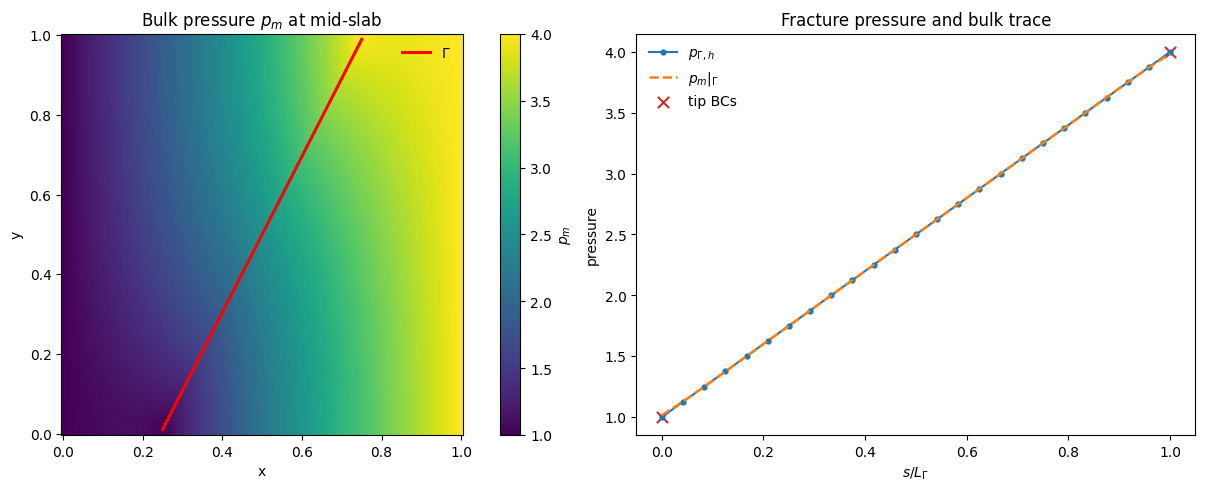

bulk p_m range on z=1.000e-02: 1 to 4
p_gamma range: 1 to 4
p_m|_Gamma range: 1.0151 to 3.9849
max |p_m|_Gamma - p_gamma|: 1.510e-02
p_gamma lower/upper tip values: 1, 4


In [4]:
# Diagnostic before flux reconstruction: inspect the coupled LCG pressure fields.
def eval_scalar_on_points(fun, points, domain=None):
    if domain is None:
        domain = fun.function_space.mesh
    points = np.asarray(points, dtype=np.float64)
    tdim_eval = domain.topology.dim
    tree = geometry.bb_tree(domain, tdim_eval)
    candidates = geometry.compute_collisions_points(tree, points)
    colliding = geometry.compute_colliding_cells(domain, candidates, points)
    cells = np.full(points.shape[0], -1, dtype=np.int32)
    for i in range(points.shape[0]):
        links = colliding.links(i)
        if len(links) > 0:
            cells[i] = links[0]
    missing = np.where(cells < 0)[0]
    if missing.size:
        midpoint_tree = geometry.create_midpoint_tree(
            domain,
            tdim_eval,
            np.arange(domain.topology.index_map(tdim_eval).size_local, dtype=np.int32),
        )
        cells[missing] = geometry.compute_closest_entity(tree, midpoint_tree, domain, points[missing])
    vals = np.asarray(fun.eval(points, cells))
    if vals.ndim == 1:
        vals = vals.reshape(-1, 1)
    return vals[:, 0]

nx_plot = ny_plot = 121
x_plot = np.linspace(xmin, xmax, nx_plot)
y_plot = np.linspace(ymin, ymax, ny_plot)
X_plot, Y_plot = np.meshgrid(x_plot, y_plot)
Z_plot = np.full(X_plot.size, Z_FRACTURE)
bulk_points = np.column_stack([X_plot.ravel(), Y_plot.ravel(), Z_plot])
P_bulk = eval_scalar_on_points(p_m, bulk_points, omega).reshape(Y_plot.shape)

gamma_xy = V_f.tabulate_dof_coordinates()[:, :2]
gamma_s = (gamma_xy - FRAC_A[None, :]) @ tau_np
gamma_t = gamma_s / L_gamma
idx_gamma = np.argsort(gamma_s)
p_gamma_vals = p_f.x.array[:len(gamma_s)]
gamma_points = V_f.tabulate_dof_coordinates().copy()
p_trace_vals = eval_scalar_on_points(p_m, gamma_points, omega)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
pc = axes[0].pcolormesh(X_plot, Y_plot, P_bulk, shading="auto", cmap="viridis")
axes[0].plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "r-", lw=2.2, label=r"$\Gamma$")
axes[0].set_aspect("equal")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title(r"Bulk pressure $p_m$ at mid-slab")
axes[0].legend(frameon=False)
fig.colorbar(pc, ax=axes[0], label=r"$p_m$")

axes[1].plot(gamma_t[idx_gamma], p_gamma_vals[idx_gamma], "o-", ms=3.5, lw=1.5, label=r"$p_{\Gamma,h}$")
axes[1].plot(gamma_t[idx_gamma], p_trace_vals[idx_gamma], "--", lw=1.8, color="tab:orange", label=r"$p_m|_\Gamma$")
axes[1].scatter([0.0, 1.0], [1.0, 4.0], marker="x", s=65, color="tab:red", label="tip BCs")
axes[1].set_xlabel(r"$s/L_\Gamma$")
axes[1].set_ylabel("pressure")
axes[1].set_title(r"Fracture pressure and bulk trace")
axes[1].legend(frameon=False)
axes[1].grid(False)
plt.show()

print(f"bulk p_m range on z={Z_FRACTURE:.3e}: {np.nanmin(P_bulk):.6g} to {np.nanmax(P_bulk):.6g}")
print(f"p_gamma range: {np.min(p_gamma_vals):.6g} to {np.max(p_gamma_vals):.6g}")
print(f"p_m|_Gamma range: {np.nanmin(p_trace_vals):.6g} to {np.nanmax(p_trace_vals):.6g}")
print(f"max |p_m|_Gamma - p_gamma|: {np.nanmax(np.abs(p_trace_vals - p_gamma_vals)):.3e}")
print(f"p_gamma lower/upper tip values: {p_gamma_vals[idx_gamma][0]:.6g}, {p_gamma_vals[idx_gamma][-1]:.6g}")


In [5]:
def polygon_signed_area(poly):
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)

def order_polygon_vertices(pts):
    pts = np.asarray(pts, dtype=float)
    ctr = pts.mean(axis=0)
    ang = np.arctan2(pts[:, 1] - ctr[1], pts[:, 0] - ctr[0])
    poly = pts[np.argsort(ang)]
    if polygon_signed_area(poly) < 0:
        poly = poly[::-1]
    return poly

def edge_length(a, b):
    return float(np.linalg.norm(np.asarray(b, dtype=float) - np.asarray(a, dtype=float)))

def outward_edge_normal(a, b, centroid):
    t = np.asarray(b, dtype=float) - np.asarray(a, dtype=float)
    n1 = np.array([t[1], -t[0]], dtype=float)
    n2 = -n1
    mid = 0.5 * (np.asarray(a, dtype=float) + np.asarray(b, dtype=float))
    chosen = n1 if np.dot(n1, mid - centroid) > 0.0 else n2
    return chosen / (np.linalg.norm(chosen) + 1e-30)

tdim = omega.topology.dim
gdim = omega.geometry.dim
omega.topology.create_connectivity(tdim, 0)
c2v = omega.topology.connectivity(tdim, 0)
omega_geometry = omega.geometry.x
num_cells = omega.topology.index_map(tdim).size_local
local_cell_vertices = [np.asarray(c2v.links(c), dtype=np.int32) for c in range(num_cells)]

cell_polys = []
for verts in local_cell_vertices:
    xy = omega_geometry[verts, :2]
    corners = np.array(
        [
            [xy[:, 0].min(), xy[:, 1].min()],
            [xy[:, 0].max(), xy[:, 1].min()],
            [xy[:, 0].max(), xy[:, 1].max()],
            [xy[:, 0].min(), xy[:, 1].max()],
        ],
        dtype=float,
    )
    cell_polys.append(corners)

cell_centroids = np.vstack([poly.mean(axis=0) for poly in cell_polys])
cell_areas = np.asarray([abs(polygon_signed_area(poly)) for poly in cell_polys])

def edge_key(x0, x1, decimals=12):
    a = tuple(np.round(x0, decimals))
    b = tuple(np.round(x1, decimals))
    return tuple(sorted((a, b)))

shadow_edges = []
seen_edges = set()
for poly in cell_polys:
    for j in range(len(poly)):
        key = edge_key(poly[j], poly[(j + 1) % len(poly)])
        if key not in seen_edges:
            seen_edges.add(key)
            shadow_edges.append((poly[j].copy(), poly[(j + 1) % len(poly)].copy()))
print("projected slab cells:", num_cells, "unique projected edges:", len(shadow_edges))

Wq = fem.functionspace(omega, ("DG", ORDER, (gdim,)))
q_cg_expr = fem.Expression(-k_m * ufl.grad(p_m), Wq.element.interpolation_points)
q_cg_fun = fem.Function(Wq, name="q_cg")
q_cg_fun.interpolate(q_cg_expr)

def as_3d_points(points, z_value=Z_FRACTURE):
    points = np.asarray(points, dtype=float)
    if points.ndim == 1:
        points = points.reshape(1, -1)
    if points.shape[1] == 3:
        return points.copy()
    return np.column_stack([points[:, :2], np.full(points.shape[0], z_value)])

def eval_fem_function(fun, points, domain=None):
    if domain is None:
        domain = fun.function_space.mesh
    pts3 = as_3d_points(points)
    tree = geometry.bb_tree(domain, domain.topology.dim)
    candidates = geometry.compute_collisions_points(tree, pts3)
    colliding = geometry.compute_colliding_cells(domain, candidates, pts3)
    valid_ids, valid_points, valid_cells = [], [], []
    for i in range(pts3.shape[0]):
        links = colliding.links(i)
        if len(links) > 0:
            valid_ids.append(i)
            valid_points.append(pts3[i])
            valid_cells.append(links[0])
    if not valid_ids:
        return np.full((pts3.shape[0], 1), np.nan)
    vals = np.asarray(fun.eval(np.asarray(valid_points), np.asarray(valid_cells, dtype=np.int32)))
    if vals.ndim == 1:
        vals = vals.reshape(len(valid_points), -1)
    out = np.full((pts3.shape[0], vals.shape[1]), np.nan)
    out[np.asarray(valid_ids, dtype=int), :] = vals
    return out

_Z_G = np.array([0.5 - 0.5 / np.sqrt(3.0), 0.5 + 0.5 / np.sqrt(3.0)], dtype=float)
_Z_W = np.array([0.5, 0.5], dtype=float)

def q_cg_numpy(points):
    # Return thickness-integrated horizontal flux Q(x,y) = int q_xy(x,y,z) dz.
    pts = np.asarray(points, dtype=float)
    if pts.ndim == 1:
        pts = pts.reshape(1, -1)
    out = np.zeros((pts.shape[0], 2), dtype=float)
    for zeta, wz in zip(_Z_G, _Z_W):
        z = zeta * THICKNESS
        pts3 = np.column_stack([pts[:, :2], np.full(pts.shape[0], z)])
        vals = eval_fem_function(q_cg_fun, pts3, omega)
        out += wz * vals[:, :2] * THICKNESS
    return out

def f_numpy(points):
    return np.zeros(np.asarray(points).shape[0], dtype=float)


projected slab cells: 4096 unique projected edges: 8320


In [6]:
def extend_line_to_bbox(a, tau, bbox, tol=1e-14):
    xmin_b, xmax_b, ymin_b, ymax_b = bbox
    ts = []
    if abs(tau[0]) > tol:
        for xval in [xmin_b, xmax_b]:
            t = (xval - a[0]) / tau[0]
            y = a[1] + t * tau[1]
            if ymin_b - tol <= y <= ymax_b + tol:
                ts.append(t)
    if abs(tau[1]) > tol:
        for yval in [ymin_b, ymax_b]:
            t = (yval - a[1]) / tau[1]
            x = a[0] + t * tau[0]
            if xmin_b - tol <= x <= xmax_b + tol:
                ts.append(t)
    if len(ts) < 2:
        raise RuntimeError("Could not extend fracture line to bounding box")
    return min(ts), max(ts)

t_min, t_max = extend_line_to_bbox(FRAC_A, tau_np, (xmin, xmax, ymin, ymax))
GHOST_START = FRAC_A + t_min * tau_np
GHOST_END = FRAC_A + t_max * tau_np

def ghost_points_np(n_each=160):
    pts = []
    if -t_min > 1e-14:
        s_left = np.linspace(t_min, 0.0, n_each, endpoint=False)
        pts.append(FRAC_A[None, :] + s_left[:, None] * tau_np[None, :])
    if t_max - L_gamma > 1e-14:
        s_right = np.linspace(L_gamma, t_max, n_each, endpoint=True)
        pts.append(FRAC_A[None, :] + s_right[:, None] * tau_np[None, :])
    return np.vstack(pts) if pts else np.zeros((0, 2))

def point_in_convex_polygon(pt, poly, tol=1e-12):
    pt = np.asarray(pt, dtype=float)
    for j in range(len(poly)):
        a = poly[j]
        b = poly[(j + 1) % len(poly)]
        edge = b - a
        cross = edge[0] * (pt[1] - a[1]) - edge[1] * (pt[0] - a[0])
        if cross < -tol:
            return False
    return True

def segment_edge_s_intersection(edge_a, edge_b, tol=1e-12):
    v = edge_b - edge_a
    A = np.column_stack((tau_np, -v))
    det = np.linalg.det(A)
    if abs(det) < tol:
        return None
    rhs = edge_a - FRAC_A
    s, u = np.linalg.solve(A, rhs)
    if -tol <= s <= L_gamma + tol and -tol <= u <= 1.0 + tol:
        return float(np.clip(s, 0.0, L_gamma))
    return None

def fracture_intervals_in_polygon(poly, tol=1e-11):
    candidates = [0.0, L_gamma]
    for j in range(len(poly)):
        s_int = segment_edge_s_intersection(poly[j], poly[(j + 1) % len(poly)])
        if s_int is not None:
            candidates.append(s_int)
    candidates = np.array(sorted(candidates), dtype=float)
    unique = []
    for s in candidates:
        if not unique or abs(s - unique[-1]) > tol:
            unique.append(float(s))
    intervals = []
    for s0, s1 in zip(unique[:-1], unique[1:]):
        if s1 - s0 <= tol:
            continue
        sm = 0.5 * (s0 + s1)
        if point_in_convex_polygon(real_points_np([sm])[0, :2], poly, tol=1e-10):
            intervals.append((s0, s1))
    return intervals

def lambda_raw_on_s(s_query):
    return eval_fem_function(lmbd, real_points_np(s_query), gamma).reshape(-1)

def integrate_lambda_interval_raw(s0, s1):
    mid = 0.5 * (s0 + s1)
    half = 0.5 * (s1 - s0)
    sq = mid + half * np.array([-1.0 / np.sqrt(3.0), 1.0 / np.sqrt(3.0)])
    return float(half * np.sum(lambda_raw_on_s(sq)))

EDGE_XI = np.array([0.5 * (1.0 - 1.0 / np.sqrt(3.0)), 0.5 * (1.0 + 1.0 / np.sqrt(3.0))], dtype=float)
EDGE_WI = np.array([0.5, 0.5], dtype=float)

def integrate_flux_polygon(poly):
    flux = 0.0
    centroid = poly.mean(axis=0)
    for j in range(len(poly)):
        x0 = poly[j]
        x1 = poly[(j + 1) % len(poly)]
        edge = x1 - x0
        n_len = outward_edge_normal(x0, x1, centroid) * edge_length(x0, x1)
        for q, w in zip(EDGE_XI, EDGE_WI):
            pt = x0 + q * edge
            flux += w * np.dot(q_cg_numpy(pt[None, :])[0], n_len)
    return float(flux)

lambda_h_cell_int_raw = np.zeros(num_cells, dtype=float)
gamma_facet_records = []
for cell_id, poly in enumerate(cell_polys):
    for s0, s1 in fracture_intervals_in_polygon(poly):
        lambda_h_cell_int_raw[cell_id] += integrate_lambda_interval_raw(s0, s1)
        gamma_facet_records.append((int(cell_id), float(s0), float(s1), float(s1 - s0)))

cell_flux_cg = np.array([integrate_flux_polygon(poly) for poly in tqdm(cell_polys, desc="CG cell flux")])
cell_source = np.zeros(num_cells, dtype=float)
R_plus = cell_flux_cg - cell_source - lambda_h_cell_int_raw
R_minus = cell_flux_cg - cell_source + lambda_h_cell_int_raw
if np.mean(np.abs(R_plus)) <= np.mean(np.abs(R_minus)):
    LAMBDA_SIGN = 1.0
    lambda_h_cell_int = lambda_h_cell_int_raw
else:
    LAMBDA_SIGN = -1.0
    lambda_h_cell_int = -lambda_h_cell_int_raw

def lambda_h_on_s(s_query):
    return LAMBDA_SIGN * lambda_raw_on_s(s_query)

print("fracture-cut cells:", len(np.unique([cid for cid, _, _, _ in gamma_facet_records])))
print("auto LAMBDA_SIGN:", LAMBDA_SIGN)
print("mean |R_CG| with selected lambda_h sign:", np.mean(np.abs(cell_flux_cg - cell_source - lambda_h_cell_int)))
print("max  |R_CG| with selected lambda_h sign:", np.max(np.abs(cell_flux_cg - cell_source - lambda_h_cell_int)))


CG cell flux: 100%|██████████| 4096/4096 [06:52<00:00,  9.92it/s]

fracture-cut cells: 94
auto LAMBDA_SIGN: 1.0
mean |R_CG| with selected lambda_h sign: 1.2930220115707823e-05
max  |R_CG| with selected lambda_h sign: 0.002617635414044624


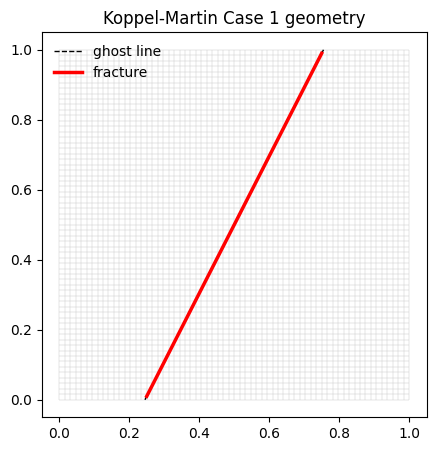

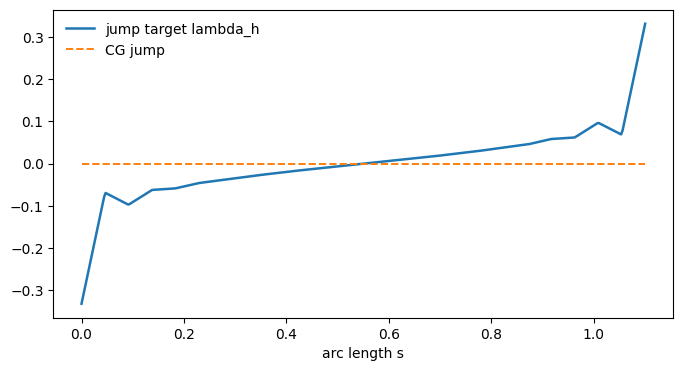

In [7]:
def cg_jump_on_fracture(s_query, eps=None):
    s_query = np.asarray(s_query, dtype=float).reshape(-1)
    if eps is None:
        eps = 0.00 * h_est
    pts = real_points_np(s_query)[:, :2]
    d_tip = np.minimum(s_query, L_gamma - s_query)
    eps_i = np.minimum(eps, 0.35 * np.maximum(d_tip, 1e-12))
    qp = q_cg_numpy(pts + eps_i[:, None] * normal_np[None, :])
    qm = q_cg_numpy(pts - eps_i[:, None] * normal_np[None, :])
    jump = np.sum((qp - qm) * normal_np[None, :], axis=1)
    return np.nan_to_num(jump, nan=0.0, posinf=0.0, neginf=0.0)

TARGET_MODE = "lambda_h"
N_REAL = max(160, 4 * max(1, len(gamma_facet_records)))
s_real = np.linspace(0.0, L_gamma, N_REAL)
x_real = real_points_np(s_real)[:, :2]
x_ghost = ghost_points_np(n_each=max(80, N_REAL // 2))
lambda_target = lambda_h_on_s(s_real) if TARGET_MODE == "lambda_h" else cg_jump_on_fracture(s_real)

def tip_weight(s, tip_frac=TIP_FRAC):
    s = np.asarray(s, dtype=float)
    d = np.minimum(s, L_gamma - s)
    return np.clip(d / (tip_frac * L_gamma + 1e-30), 0.05, 1.0)

w_tip = tip_weight(s_real)

fig, ax = plt.subplots(figsize=(5, 5))
ax.add_collection(LineCollection([np.vstack([p0, p1]) for p0, p1 in shadow_edges], colors="0.80", linewidths=0.35))
ax.plot([GHOST_START[0], GHOST_END[0]], [GHOST_START[1], GHOST_END[1]], "k--", lw=1.0, label="ghost line")
ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "r-", lw=2.5, label="fracture")
ax.set_aspect("equal")
ax.legend(frameon=False)
ax.set_title("Koppel-Martin Case 1 geometry")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(s_real, lambda_target, lw=1.8, label="jump target lambda_h")
ax.plot(s_real, cg_jump_on_fracture(s_real), "--", lw=1.4, label="CG jump")
ax.set_xlabel("arc length s")
ax.legend(frameon=False)
ax.grid(False)
plt.show()


In [8]:
class AdaptiveTanh(nn.Module):
    def __init__(self, n=5.0):
        super().__init__()
        self.a = nn.Parameter(torch.tensor(1.0 / n))
    def forward(self, x):
        return torch.tanh(self.a * x)

class FluxNet(nn.Module):
    def __init__(self, in_dim=2, out_dim=2, hidden_dim=64, num_hidden_layers=4, n=5.0):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), AdaptiveTanh(n=n)]
        for _ in range(num_hidden_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), AdaptiveTanh(n=n)]
        layers.append(nn.Linear(hidden_dim, out_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)
    def slope_recovery_term(self):
        slopes = [m.a for m in self.net if isinstance(m, AdaptiveTanh)]
        return 1.0 / torch.mean(torch.exp(torch.stack(slopes)))

xy_center_np = np.array([(xmin + xmax) / 2.0, (ymin + ymax) / 2.0], dtype=float)
xy_scale = float(max(xmax - xmin, ymax - ymin))
xy_center_t = torch.tensor(xy_center_np, dtype=torch.float32, device=device)
tau_t = torch.tensor(tau_np, dtype=torch.float32, device=device)
normal_t = torch.tensor(normal_np, dtype=torch.float32, device=device)
frac_a_t = torch.tensor(FRAC_A, dtype=torch.float32, device=device)

def to_torch(x, requires_grad=False):
    t = torch.as_tensor(np.asarray(x, dtype=np.float32), device=device)
    if requires_grad:
        t = t.clone().detach().requires_grad_(True)
    return t

def normalize_xy(x):
    return (x - xy_center_t) / xy_scale

q_plus_net = FluxNet(hidden_dim=48, num_hidden_layers=4).to(device)
q_minus_net = FluxNet(hidden_dim=48, num_hidden_layers=4).to(device)

def signed_distance_torch(x):
    return (x - frac_a_t) @ normal_t

def q_plus(x):
    return q_plus_net(normalize_xy(x))

def q_minus(x):
    return q_minus_net(normalize_xy(x))

def q_piecewise(x):
    phi = signed_distance_torch(x)
    qp = q_plus(x)
    qm = q_minus(x)
    return torch.where((phi >= 0.0).reshape(-1, 1), qp, qm)

def div_of_q(net_fn, x):
    x = x.clone().detach().requires_grad_(True)
    q = net_fn(x)
    dq0 = torch.autograd.grad(q[:, 0].sum(), x, create_graph=True)[0][:, 0]
    dq1 = torch.autograd.grad(q[:, 1].sum(), x, create_graph=True)[0][:, 1]
    return dq0 + dq1


In [9]:
N_PTS_PER_EDGE = 3
MASK_FACTOR_START = 0.15
MASK_FACTOR_END = 1.15

edge_sample_pts = []
for x0, x1 in shadow_edges:
    ts = np.linspace(0.0, 1.0, N_PTS_PER_EDGE + 2)[1:-1]
    for t in ts:
        edge_sample_pts.append(x0 + t * (x1 - x0))
edge_sample_pts = np.array(edge_sample_pts, dtype=float)
phi_edge = signed_distance_np(edge_sample_pts)
Q_data_all = q_cg_numpy(edge_sample_pts)
valid = np.all(np.isfinite(Q_data_all), axis=1)
X_data = edge_sample_pts[valid]
Q_data = Q_data_all[valid]
phi_data = phi_edge[valid]
data_mask = np.abs(phi_data) > MASK_FACTOR_START * h_est
data_mask_final = np.abs(phi_data) > MASK_FACTOR_END * h_est

X_data_t = to_torch(X_data)
Q_data_t = to_torch(Q_data)
data_idx_start_t = torch.tensor(np.nonzero(data_mask)[0], dtype=torch.long, device=device)
data_idx_final_t = torch.tensor(np.nonzero(data_mask_final)[0], dtype=torch.long, device=device)

X_div = cell_centroids
phi_div = signed_distance_np(X_div)
div_mask = np.abs(phi_div) > MASK_FACTOR_START * h_est
div_mask_final = np.abs(phi_div) > MASK_FACTOR_END * h_est
X_div_t = to_torch(X_div)
F_div_t = torch.zeros(len(X_div), dtype=torch.float32, device=device)
div_idx_start_t = torch.tensor(np.nonzero(div_mask)[0], dtype=torch.long, device=device)
div_idx_final_t = torch.tensor(np.nonzero(div_mask_final)[0], dtype=torch.long, device=device)
side_div_t = signed_distance_torch(X_div_t) >= 0.0

X_real_t = to_torch(x_real)
Lambda_target_t = to_torch(lambda_target)
W_tip_t = to_torch(w_tip)
X_ghost_t = to_torch(x_ghost)

def build_edge_quadrature_for_cells(cell_ids):
    xi = np.array([0.5 * (1 - 1 / np.sqrt(3)), 0.5 * (1 + 1 / np.sqrt(3))], dtype=float)
    wi = np.array([0.5, 0.5], dtype=float)
    edge_points, edge_nw, edge_cells = [], [], []
    source, cg_flux, lambda_h_int = [], [], []
    local_id_of_cell = {}
    for local_i, cell_id in enumerate(cell_ids):
        local_id_of_cell[int(cell_id)] = local_i
        poly = cell_polys[int(cell_id)]
        source.append(cell_source[int(cell_id)])
        cg_flux.append(cell_flux_cg[int(cell_id)])
        lambda_h_int.append(lambda_h_cell_int[int(cell_id)])
        centroid = poly.mean(axis=0)
        for j in range(len(poly)):
            x0 = poly[j]
            x1 = poly[(j + 1) % len(poly)]
            edge = x1 - x0
            n_len = outward_edge_normal(x0, x1, centroid) * edge_length(x0, x1)
            for q, w in zip(xi, wi):
                edge_points.append(x0 + q * edge)
                edge_nw.append(w * n_len)
                edge_cells.append(local_i)
    return {
        "cell_ids": np.asarray(cell_ids, dtype=np.int32),
        "edge_points": np.asarray(edge_points),
        "edge_nw": np.asarray(edge_nw),
        "edge_cells": np.asarray(edge_cells, dtype=np.int64),
        "source": np.asarray(source),
        "cg_flux": np.asarray(cg_flux),
        "lambda_h_int": np.asarray(lambda_h_int),
        "local_id_of_cell": local_id_of_cell,
    }

_frac_cids = np.unique([cid for cid, _, _, _ in gamma_facet_records])
_frac_quad = build_edge_quadrature_for_cells(_frac_cids)
N_frac_cons = len(_frac_cids)
frac_eq_pts_t = to_torch(_frac_quad["edge_points"])
frac_eq_nw_t = to_torch(_frac_quad["edge_nw"])
frac_eq_cells_t = torch.tensor(_frac_quad["edge_cells"], dtype=torch.long, device=device)
frac_source_t = to_torch(_frac_quad["source"])
frac_lambda_t = to_torch(_frac_quad["lambda_h_int"])
frac_s_np = s_coord_np(cell_centroids[_frac_cids])
frac_cons_tip_np = (frac_s_np < TIP_FRAC * L_gamma) | (frac_s_np > (1.0 - TIP_FRAC) * L_gamma)
frac_cons_int_np = ~frac_cons_tip_np
frac_cons_tip_t = torch.tensor(frac_cons_tip_np, dtype=torch.bool, device=device)
frac_cons_int_t = torch.tensor(frac_cons_int_np, dtype=torch.bool, device=device)

print(f"flux data pool: {len(X_data)}")
print(f"data_mask points ({MASK_FACTOR_START:.2f}h -> {MASK_FACTOR_END:.2f}h):", np.count_nonzero(data_mask), "->", np.count_nonzero(data_mask_final))
print("div collocation pool:", len(X_div))
print(f"fracture-cut cells for conservation loss: {N_frac_cons}")


flux data pool: 24960
data_mask points (0.15h -> 1.15h): 24824 -> 23962
div collocation pool: 4096
fracture-cut cells for conservation loss: 94


In [ ]:
W_DATA = 5.0
W_DIV = 2.0
W_CONS_INT = 0.10
W_CONS_TIP = 0.10
CONS_INT_BETA = 1.0
CONS_R_FLOOR = 1e-5
CONS_INT_GAMMA = 4.0
W_JUMP = 1.0
W_GHOST = 2.0
W_SLOPE = 1e-4

EPOCHS = 5000
CONS_RAMP_START = int(0.6 * EPOCHS)
CONS_RAMP_END = int(1.0 * EPOCHS)
BEST_START_EPOCH = CONS_RAMP_END
BATCH_DATA = 8192
BATCH_DIV = 4096

optimizer_plus = torch.optim.Adam(q_plus_net.parameters(), lr=2e-3)
optimizer_minus = torch.optim.Adam(q_minus_net.parameters(), lr=2e-3)
scheduler_plus = torch.optim.lr_scheduler.MultiStepLR(optimizer_plus, milestones=[int(0.45 * EPOCHS), int(0.75 * EPOCHS)], gamma=0.35)
scheduler_minus = torch.optim.lr_scheduler.MultiStepLR(optimizer_minus, milestones=[int(0.45 * EPOCHS), int(0.75 * EPOCHS)], gamma=0.35)

def mse(x):
    return torch.mean(x ** 2)

def smoothstep01(t):
    t = float(np.clip(t, 0.0, 1.0))
    return t * t * (3.0 - 2.0 * t)

def curriculum_for_epoch(epoch):
    t = (epoch - CONS_RAMP_START) / max(CONS_RAMP_END - CONS_RAMP_START, 1)
    ramp = smoothstep01(t)
    use_final_mask = epoch >= CONS_RAMP_START
    data_pool = data_idx_final_t if use_final_mask else data_idx_start_t
    div_pool = div_idx_final_t if use_final_mask else div_idx_start_t
    mask_factor = MASK_FACTOR_END if use_final_mask else MASK_FACTOR_START
    return ramp, mask_factor, data_pool, div_pool

def compute_loss_terms(epoch):
    cons_ramp, mask_factor, data_pool, div_pool = curriculum_for_epoch(epoch)
    n_data_epoch = data_pool.numel()
    idx_d = data_pool[torch.randint(0, n_data_epoch, (min(BATCH_DATA, n_data_epoch),), device=device)]
    loss_data = mse(q_piecewise(X_data_t[idx_d]) - Q_data_t[idx_d])

    n_div_epoch = div_pool.numel()
    idx_v = div_pool[torch.randint(0, n_div_epoch, (min(BATCH_DIV, n_div_epoch),), device=device)]
    x_div_b = X_div_t[idx_v]
    side_b = side_div_t[idx_v]
    div_loss = torch.tensor(0.0, device=device)
    Xp = x_div_b[side_b]
    Xm = x_div_b[~side_b]
    if Xp.numel() > 0:
        div_loss = div_loss + mse(div_of_q(q_plus, Xp))
    if Xm.numel() > 0:
        div_loss = div_loss + mse(div_of_q(q_minus, Xm))

    q_edge = q_piecewise(frac_eq_pts_t)
    flux_q = torch.sum(q_edge * frac_eq_nw_t, dim=1)
    flux_K = torch.zeros(N_frac_cons, device=device)
    flux_K.scatter_add_(0, frac_eq_cells_t, flux_q)
    R_rec_frac = flux_K - frac_source_t - frac_lambda_t
    loss_cons_frac = mse(R_rec_frac)

    loss_cons_int = torch.tensor(0.0, device=device)
    if frac_cons_int_t.any().item():
        R_rec_int = R_rec_frac[frac_cons_int_t]
        R_cg_int = torch.as_tensor(
            (cell_flux_cg[_frac_cids] - cell_source[_frac_cids] - lambda_h_cell_int[_frac_cids])[frac_cons_int_np],
            dtype=torch.float32,
            device=device,
        )
        R_cg_abs = torch.abs(R_cg_int)
        denom = torch.clamp(R_cg_abs, min=CONS_R_FLOOR)
        excess = torch.relu(torch.abs(R_rec_int) - CONS_INT_BETA * R_cg_abs)
        loss_cons_int = torch.mean((R_rec_int / denom) ** 2) + CONS_INT_GAMMA * torch.mean((excess / denom) ** 2)

    loss_cons_tip = torch.tensor(0.0, device=device)
    if frac_cons_tip_t.any().item():
        loss_cons_tip = mse(R_rec_frac[frac_cons_tip_t])

    qp_real = q_plus(X_real_t)
    qm_real = q_minus(X_real_t)
    jump_real = torch.sum((qp_real - qm_real) * normal_t.reshape(1, 2), dim=1)
    loss_jump = torch.mean(W_tip_t * (jump_real - Lambda_target_t) ** 2)
    loss_ghost = mse(q_plus(X_ghost_t) - q_minus(X_ghost_t)) if X_ghost_t.numel() > 0 else torch.tensor(0.0, device=device)
    loss_slope = q_plus_net.slope_recovery_term() + q_minus_net.slope_recovery_term()

    total = (
        W_DATA * loss_data
        + W_DIV * div_loss
        + cons_ramp * W_CONS_INT * loss_cons_int
        + cons_ramp * W_CONS_TIP * loss_cons_tip
        + W_JUMP * loss_jump
        + W_GHOST * loss_ghost
        + W_SLOPE * loss_slope
    )
    parts = {
        "data": loss_data.detach(),
        "div": div_loss.detach(),
        "cons_frac": loss_cons_frac.detach(),
        "cons_int": loss_cons_int.detach(),
        "cons_tip": loss_cons_tip.detach(),
        "jump": loss_jump.detach(),
        "ghost": loss_ghost.detach(),
        "slope": loss_slope.detach(),
        "cons_ramp": torch.tensor(cons_ramp, device=device),
        "mask_factor": torch.tensor(mask_factor, device=device),
    }
    return total, parts

history = []
best_state = None
best_loss = float("inf")
t0 = time.perf_counter()
for epoch in range(1, EPOCHS + 1):
    optimizer_plus.zero_grad(set_to_none=True)
    optimizer_minus.zero_grad(set_to_none=True)
    total, parts = compute_loss_terms(epoch)
    total.backward()
    torch.nn.utils.clip_grad_norm_(list(q_plus_net.parameters()) + list(q_minus_net.parameters()), max_norm=1.0)
    optimizer_plus.step()
    optimizer_minus.step()
    scheduler_plus.step()
    scheduler_minus.step()

    row = {"epoch": epoch, "total": float(total.detach().cpu())}
    row.update({k: float(v.detach().cpu()) for k, v in parts.items()})
    history.append(row)
    if epoch >= BEST_START_EPOCH and row["total"] < best_loss:
        best_loss = row["total"]
        best_state = {
            "plus": {k: v.detach().cpu().clone() for k, v in q_plus_net.state_dict().items()},
            "minus": {k: v.detach().cpu().clone() for k, v in q_minus_net.state_dict().items()},
            "epoch": epoch,
        }
    if epoch == 1 or epoch % 250 == 0:
        print(
            f"{epoch:6d} total={row['total']:.3e} ramp={row['cons_ramp']:.2f} "
            f"data={row['data']:.3e} div={row['div']:.3e} cons={row['cons_frac']:.3e} "
            f"jump={row['jump']:.3e} ghost={row['ghost']:.3e}"
        )

if best_state is not None:
    q_plus_net.load_state_dict(best_state["plus"])
    q_minus_net.load_state_dict(best_state["minus"])
    print("restored best epoch:", best_state["epoch"], "loss:", best_loss)
print(f"training time: {time.perf_counter() - t0:.1f} s")


     1 total=2.197e-03 ramp=0.00 data=1.278e-04 div=1.931e-06 cons=5.595e-07 jump=1.271e-03 ghost=6.655e-05
   250 total=2.081e-03 ramp=0.00 data=1.080e-04 div=1.965e-06 cons=5.420e-07 jump=1.205e-03 ghost=9.239e-05
   500 total=1.964e-03 ramp=0.00 data=9.057e-05 div=1.695e-06 cons=5.401e-07 jump=1.188e-03 ghost=8.703e-05
   750 total=1.925e-03 ramp=0.00 data=8.459e-05 div=3.391e-06 cons=5.430e-07 jump=1.194e-03 ghost=7.791e-05
  1000 total=1.936e-03 ramp=0.00 data=8.572e-05 div=1.388e-05 cons=5.471e-07 jump=1.203e-03 ghost=6.658e-05
  1250 total=1.922e-03 ramp=0.00 data=8.211e-05 div=8.053e-06 cons=5.368e-07 jump=1.169e-03 ghost=9.145e-05
  1500 total=1.909e-03 ramp=0.00 data=8.023e-05 div=1.095e-05 cons=5.396e-07 jump=1.175e-03 ghost=8.386e-05
  1750 total=1.871e-03 ramp=0.00 data=7.942e-05 div=1.728e-06 cons=5.445e-07 jump=1.188e-03 ghost=6.964e-05
  2000 total=1.875e-03 ramp=0.00 data=7.959e-05 div=1.052e-06 cons=5.459e-07 jump=1.193e-03 ghost=7.010e-05
  2250 total=1.887e-03 ramp=

Ghost-partition PINN reconstruction:
  all CG : {'mean': 1.293022011570782e-05, 'median': 2.506524108575217e-07, 'max': 0.002617635414044624}
  all PINN: {'mean': 8.251186481083431e-06, 'median': 1.0301300790160894e-07, 'max': 0.003986578400005896}
  fracture CG : {'mean': 0.00029935680868747324, 'median': 0.00022517827947692682, 'max': 0.002617635414044624}
  fracture PINN: {'mean': 0.00035243105874592506, 'median': 0.0001548070428323053, 'max': 0.003986578400005896}


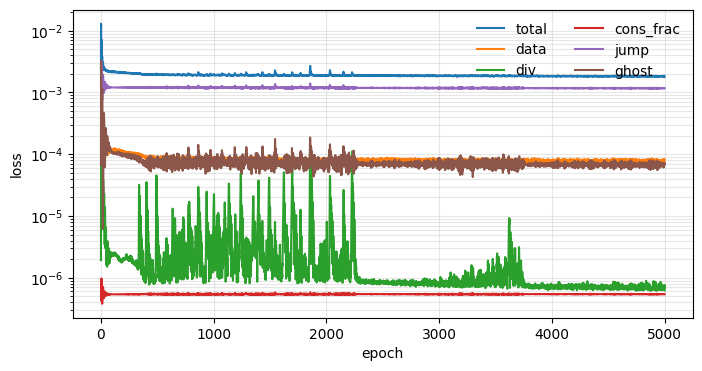

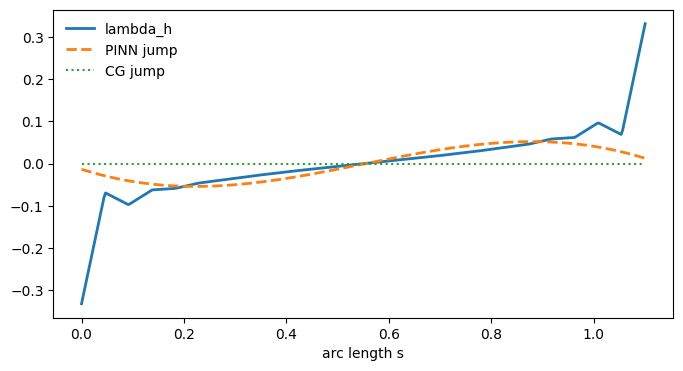

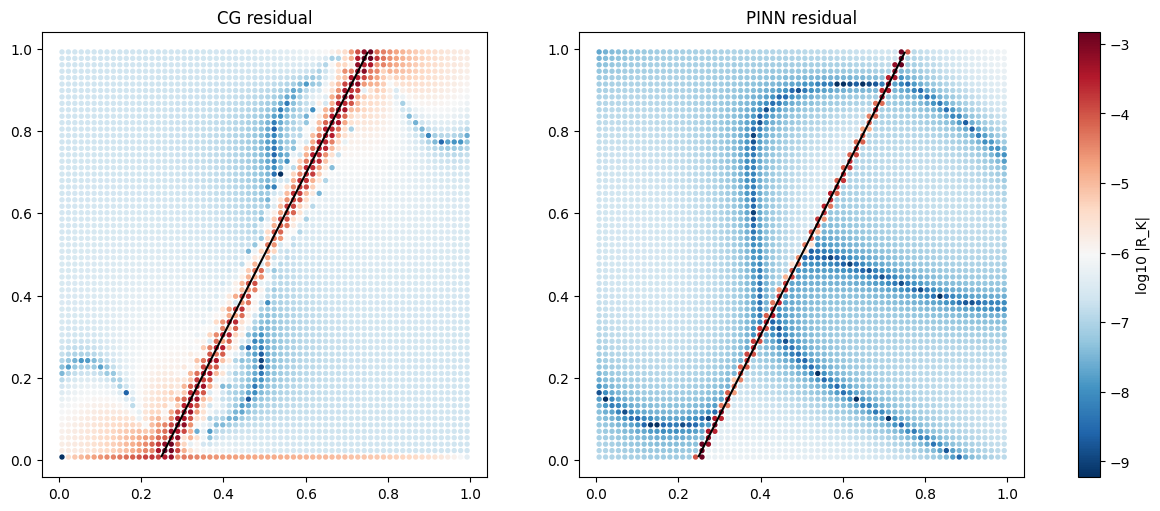

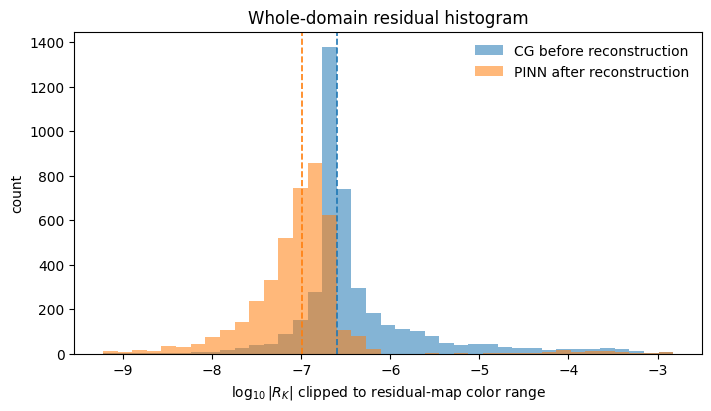

In [23]:
@torch.no_grad()
def q_rec_numpy(points, batch=200000):
    pts = np.asarray(points, dtype=float)
    out = []
    for i in range(0, len(pts), batch):
        xb = to_torch(pts[i:i + batch, :2])
        out.append(q_piecewise(xb).detach().cpu().numpy())
    return np.vstack(out) if out else np.zeros((0, 2))

@torch.no_grad()
def jump_rec_numpy(s):
    pts = real_points_np(s)[:, :2]
    xb = to_torch(pts)
    qp = q_plus(xb)
    qm = q_minus(xb)
    return torch.sum((qp - qm) * normal_t.reshape(1, 2), dim=1).detach().cpu().numpy()

def compute_lce_for_cells(cell_ids):
    data = build_edge_quadrature_for_cells(cell_ids)
    q_rec = q_rec_numpy(data["edge_points"])
    flux_rec_q = np.sum(q_rec * data["edge_nw"], axis=1)
    flux_cg_q = np.sum(q_cg_numpy(data["edge_points"]) * data["edge_nw"], axis=1)
    flux_rec = np.zeros(len(data["cell_ids"]), dtype=float)
    flux_cg = np.zeros(len(data["cell_ids"]), dtype=float)
    np.add.at(flux_rec, data["edge_cells"], flux_rec_q)
    np.add.at(flux_cg, data["edge_cells"], flux_cg_q)
    R_rec = flux_rec - data["source"] - data["lambda_h_int"]
    R_cg = flux_cg - data["source"] - data["lambda_h_int"]
    return data, R_cg, R_rec

all_cell_ids = np.arange(num_cells, dtype=np.int32)
diag_data, R_cg, R_rec = compute_lce_for_cells(all_cell_ids)
frac_cell_ids = np.unique([cid for cid, _, _, _ in gamma_facet_records]).astype(np.int32)

def residual_stats(vals, ids=None):
    vals = np.asarray(vals if ids is None else vals[ids], dtype=float)
    return {
        "mean": float(np.mean(np.abs(vals))),
        "median": float(np.median(np.abs(vals))),
        "max": float(np.max(np.abs(vals))),
    }

print("Ghost-partition PINN reconstruction:")
print("  all CG :", residual_stats(R_cg))
print("  all PINN:", residual_stats(R_rec))
print("  fracture CG :", residual_stats(R_cg, frac_cell_ids))
print("  fracture PINN:", residual_stats(R_rec, frac_cell_ids))

hist = {k: np.array([row[k] for row in history]) for k in history[0].keys()}
fig, ax = plt.subplots(figsize=(8, 4))
for key in ["total", "data", "div", "cons_frac", "jump", "ghost"]:
    ax.semilogy(hist["epoch"], hist[key], label=key)
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.legend(ncol=2, frameon=False)
ax.grid(True, which="both", alpha=0.3)
plt.show()

jump_rec = jump_rec_numpy(s_real)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(s_real, lambda_target, lw=2, label="lambda_h")
ax.plot(s_real, jump_rec, "--", lw=2, label="PINN jump")
ax.plot(s_real, cg_jump_on_fracture(s_real), ":", lw=1.5, label="CG jump")
ax.set_xlabel("arc length s")
ax.legend(frameon=False)
ax.grid(False)
plt.show()

eps = 1e-16
log_R_cg = np.log10(np.abs(R_cg) + eps)
log_R_rec = np.log10(np.abs(R_rec) + eps)
res_color_values = np.concatenate([log_R_cg[np.isfinite(log_R_cg)], log_R_rec[np.isfinite(log_R_rec)]])
res_vmin, res_vmax = np.percentile(res_color_values, [0.1, 99.9])
if not np.isfinite(res_vmin) or not np.isfinite(res_vmax) or res_vmin >= res_vmax:
    res_vmin = min(np.nanmin(log_R_cg), np.nanmin(log_R_rec))
    res_vmax = max(np.nanmax(log_R_cg), np.nanmax(log_R_rec))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, vals, title in [
    (axes[0], log_R_cg, "CG residual"),
    (axes[1], log_R_rec, "PINN residual"),
]:
    sc = ax.scatter(cell_centroids[:, 0], cell_centroids[:, 1], c=vals, s=8, cmap="RdBu_r", vmin=res_vmin, vmax=res_vmax)
    ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "k-", lw=1.5)
    ax.set_aspect("equal")
    ax.set_title(title)
fig.colorbar(sc, ax=axes.ravel().tolist(), label="log10 |R_K|")
plt.show()

hist_vmin, hist_vmax = res_vmin, res_vmax
log_R_cg_hist = np.clip(log_R_cg[np.isfinite(log_R_cg)], hist_vmin, hist_vmax)
log_R_rec_hist = np.clip(log_R_rec[np.isfinite(log_R_rec)], hist_vmin, hist_vmax)
hist_bins = np.linspace(hist_vmin, hist_vmax, 40)

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.hist(log_R_cg_hist, bins=hist_bins, alpha=0.55, color="C0", label="CG before reconstruction")
ax.hist(log_R_rec_hist, bins=hist_bins, alpha=0.55, color="C1", label="PINN after reconstruction")
ax.axvline(np.median(log_R_cg_hist), color="C0", ls="--", lw=1.2)
ax.axvline(np.median(log_R_rec_hist), color="C1", ls="--", lw=1.2)
ax.set_xlabel(r"$\log_{10}|R_K|$ clipped to residual-map color range")
ax.set_ylabel("count")
ax.set_title(r"Whole-domain residual histogram")
ax.legend(frameon=False)
ax.grid(False)
plt.show()


fracture-cut residual scatter cells: 94 / 4096


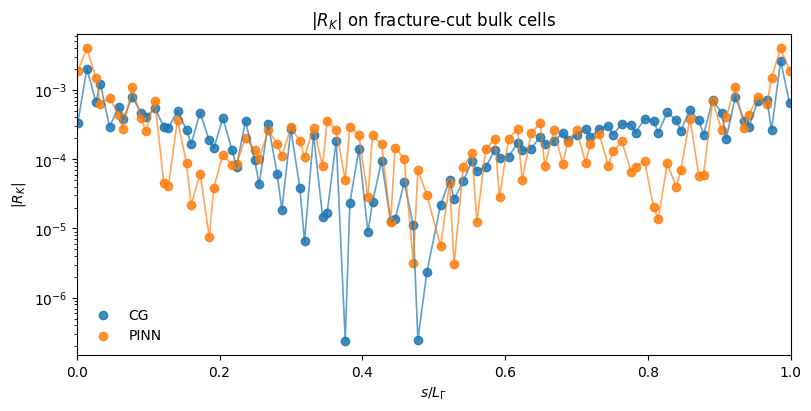

In [24]:
# R_K scatter diagnostic restricted to bulk cells cut by the fracture
diag_cell_ids = np.asarray(diag_data["cell_ids"], dtype=np.int32)
cut_cell_ids = np.asarray(frac_cell_ids, dtype=np.int32)
diag_position = {int(cid): i for i, cid in enumerate(diag_cell_ids)}
cut_diag_pos = np.array([diag_position[int(cid)] for cid in cut_cell_ids if int(cid) in diag_position], dtype=np.int32)
cut_plot_cell_ids = diag_cell_ids[cut_diag_pos]

print(f"fracture-cut residual scatter cells: {len(cut_plot_cell_ids)} / {num_cells}")
if len(cut_plot_cell_ids) == 0:
    raise RuntimeError("No fracture-cut cells were found in diag_data; check gamma_facet_records.")

cut_s = ((cell_centroids[cut_plot_cell_ids, :2] - FRAC_A[None, :]) @ tau_np) / L_gamma
cut_order = np.argsort(cut_s)
cut_s = cut_s[cut_order]
eps = 1e-16
cut_R_cg = np.abs(R_cg[cut_diag_pos][cut_order]) + eps
cut_R_rec = np.abs(R_rec[cut_diag_pos][cut_order]) + eps

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
ax.plot(cut_s, cut_R_cg, lw=1.2, alpha=0.7, color="C0")
ax.plot(cut_s, cut_R_rec, lw=1.2, alpha=0.7, color="C1")
ax.scatter(cut_s, cut_R_cg, s=36, alpha=0.85, color="C0", label="CG")
ax.scatter(cut_s, cut_R_rec, s=36, alpha=0.85, color="C1", label="PINN")
ax.set_xlabel(r"$s/L_\Gamma$")
ax.set_ylabel(r"$|R_K|$")
ax.set_title(r"$|R_K|$ on fracture-cut bulk cells")
ax.set_xlim(0.0, 1.0)
ax.set_yscale("log")
ax.legend(frameon=False)
ax.grid(False)
plt.show()


In [21]:
outdir = pathlib.Path("result_koppel_martin_case1_pinn")
outdir.mkdir(exist_ok=True)
torch.save(
    {
        "q_plus": q_plus_net.state_dict(),
        "q_minus": q_minus_net.state_dict(),
        "FRAC_A": FRAC_A,
        "FRAC_B": FRAC_B,
        "GHOST_START": GHOST_START,
        "GHOST_END": GHOST_END,
        "normal": normal_np,
        "tau": tau_np,
        "LAMBDA_SIGN": LAMBDA_SIGN,
        "TARGET_MODE": TARGET_MODE,
        "xy_center": xy_center_np,
        "xy_scale": xy_scale,
        "thickness": THICKNESS,
    },
    outdir / "km_case1_pinn_flux.pt",
)
np.savez(
    outdir / "diagnostics.npz",
    cell_ids=diag_data["cell_ids"],
    centroids=cell_centroids,
    R_cg=R_cg,
    R_rec=R_rec,
    frac_cell_ids=frac_cell_ids,
    s_real=s_real,
    lambda_target=lambda_target,
    jump_rec=jump_rec,
    jump_cg=cg_jump_on_fracture(s_real),
)
print("saved:", outdir)


saved: result_koppel_martin_case1_pinn
